# Metode Numerik — Persamaan Deformasi Jaringan Lunak
## *Soft Tissue Exponential Deformation Equation*

**Nama :** Muhammad Izzudin Yusuf  
**NIM  :** 25/560389/TK/63290  
**Kelas:** C – Teknik Biomedis  

---

## 1. Model Matematika

Persamaan deformasi eksponensial jaringan lunak (*heart chordae tendineae*):

$$ \sigma = \frac{E_0}{a}\left(e^{a\varepsilon} - 1\right) \tag{1} $$

Bentuk akar yang akan diselesaikan:

$$ f(\varepsilon) = \frac{E_0}{a}\left(e^{a\varepsilon} - 1\right) - \sigma_{target} = 0 \tag{2} $$

**Keterangan variabel:**
- $\varepsilon$ : regangan aksial jaringan (strain, tak berdimensi)
- $\sigma$ : tegangan mekanis jaringan (stress, $\mathrm{N/m^2}$)
- $E_0, a$ : konstanta material jaringan lunak (ditentukan eksperimen)

> **Sumber:** Chapra, S. C., & Canale, R. P. (2015). *Numerical Methods for Engineers* (7th ed., hlm. 684, Problem 24.9). McGraw-Hill Education.

Turunan pertama & kedua (diperlukan Newton):

$$ f'(\varepsilon) = E_0 e^{a\varepsilon}, \qquad f''(\varepsilon) = E_0 a e^{a\varepsilon} $$

Diferensial model untuk identifikasi konstanta (fundamental soft tissue):

$$ \frac{d\sigma}{d\varepsilon} = E_0 + a\,\sigma \tag{3} $$

Persamaan (3) linier: $y = mx + c$.



In [41]:

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

# --- DATA EKSPERIMEN (Chapra & Canale 7th ed, Problem 24.9) ---
# sigma_all = tegangan σ (N/m²), 13 titik; eps_all = regangan ε (tak berdimensi)
sigma_all = np.array([87.8,96.6,176,263,350,569,833,1227,1623,2105,2677,3378,4257], dtype=float)*1000
eps_all   = np.array([153,198,270,320,355,410,460,512,562,614,664,716,766], dtype=float)*1e-3

print(f"Jumlah titik data: {len(sigma_all)}")
for i,(s,e) in enumerate(zip(sigma_all, eps_all), start=1):
    print(f" i={i:2d}  sigma={s:8.0f} N/m2   eps={e:.3f}")


Jumlah titik data: 13
 i= 1  sigma=   87800 N/m2   eps=0.153
 i= 2  sigma=   96600 N/m2   eps=0.198
 i= 3  sigma=  176000 N/m2   eps=0.270
 i= 4  sigma=  263000 N/m2   eps=0.320
 i= 5  sigma=  350000 N/m2   eps=0.355
 i= 6  sigma=  569000 N/m2   eps=0.410
 i= 7  sigma=  833000 N/m2   eps=0.460
 i= 8  sigma= 1227000 N/m2   eps=0.512
 i= 9  sigma= 1623000 N/m2   eps=0.562
 i=10  sigma= 2105000 N/m2   eps=0.614
 i=11  sigma= 2677000 N/m2   eps=0.664
 i=12  sigma= 3378000 N/m2   eps=0.716
 i=13  sigma= 4257000 N/m2   eps=0.766


## 2. Penurunan *Centered Finite Difference* (Orde $O(\Delta\varepsilon^2)$)

Deret Taylor di sekitar $\varepsilon_i$:

$$\sigma_{i+1} = \sigma_i + \left.\frac{d\sigma}{d\varepsilon}\right|_i \Delta\varepsilon + \frac12\left.\frac{d^2\sigma}{d\varepsilon^2}\right|_i \Delta\varepsilon^2 + \frac16\left.\frac{d^3\sigma}{d\varepsilon^3}\right|_i \Delta\varepsilon^3 + \cdots \tag{pers. 1}$$

$$\sigma_{i-1} = \sigma_i - \left.\frac{d\sigma}{d\varepsilon}\right|_i \Delta\varepsilon + \frac12\left.\frac{d^2\sigma}{d\varepsilon^2}\right|_i \Delta\varepsilon^2 - \frac16\left.\frac{d^3\sigma}{d\varepsilon^3}\right|_i \Delta\varepsilon^3 + \cdots \tag{pers. 2}$$

Kurangkan (pers. 1)–(pers. 2) untuk eliminasi suku orde genap ($\Delta\varepsilon^2$):

$$\sigma_{i+1} - \sigma_{i-1} = 2\left.\frac{d\sigma}{d\varepsilon}\right|_i \Delta\varepsilon + \frac13\left.\frac{d^3\sigma}{d\varepsilon^3}\right|_i \Delta\varepsilon^3 + \cdots$$

Abaikan galat orde tinggi, bagi $2\Delta\varepsilon = \varepsilon_{i+1}-\varepsilon_{i-1}$:

$$ y_i = \left.\frac{d\sigma}{d\varepsilon}\right|_i \approx \frac{\sigma_{i+1}-\sigma_{i-1}}{\varepsilon_{i+1}-\varepsilon_{i-1}} \tag{4} $$

Galat pemotongan $O(\Delta\varepsilon^2)$ — jauh lebih kecil daripada *forward/backward* $O(\Delta\varepsilon)$.

> **Bukti numerik** (model eksponensial sebagai acuan eksak, titik i = 8, Δε ≈ 0,05): galat relatif forward 11,43% (mewakili skema satu-sisi O(h); backward terukur 10,29%, sekelas), **centered 0,36%** (~30× lebih kecil; hanya forward yang digambar agar garis tak bertumpuk). Uji paruh-langkah di ε = 0,35: h = 0,050 → 0,025 mengecilkan galat forward ÷2 (7,69 → 3,71 × 10⁵, ciri O(h)) dan centered **÷4** (5,09 → 1,27 × 10⁴, ciri O(h²)) – lihat gambar sel berikut (garis sejajar acuan kemiringan 1 dan 2).
>
> *Catatan: ini galat pemotongan terhadap fungsi mulus; selisih $y_{\text{data}}$ vs $y_{\text{model}}$ di Subbab 4.2 dominan dari noise/diskrepansi model, bukan skema beda-hingga.*

**Catatan:** Titik $i=1$ ($\sigma=87\,800\,\mathrm{N/m^2}$) dan $i=13$ ($\sigma=4\,257\,000\,\mathrm{N/m^2}$) adalah *boundary points* — tidak punya tetangga lengkap — sehingga hanya **11 titik internal** ($i=2..12$) dipakai untuk regresi.


In [42]:
# --- Hitung y_i dengan rumus (4): y = (σᵢ₊₁−σᵢ₋₁)/(εᵢ₊₁−εᵢ₋₁) ---
# Boundary i=1,13 -> NaN; hanya 11 titik internal i=2..12 untuk regresi.
y_num = np.full_like(sigma_all, np.nan, dtype=float)
for i in range(1, len(sigma_all)-1):
    y_num[i] = (sigma_all[i+1]-sigma_all[i-1])/(eps_all[i+1]-eps_all[i-1])

print("Verifikasi y_i (centered):")
for i in range(1, len(sigma_all)-1):
    print(f" i={i+1:2d}  sigma={sigma_all[i]:7.0f}  y≈{y_num[i]:10.0f} N/m2")

# x_reg ≡ x = σ; y_reg ≡ y = dσ/dε (11 titik); y_by_i = akses aman per indeks i (1-based)
mask = ~np.isnan(y_num)
x_reg = sigma_all[mask]
y_reg = y_num[mask]
y_by_i = {i+1: y_num[i] for i in range(len(y_num)) if not np.isnan(y_num[i])}
print(f"\nData regresi: n={len(x_reg)} titik")


Verifikasi y_i (centered):
 i= 2  sigma=  96600  y≈    753846 N/m2
 i= 3  sigma= 176000  y≈   1363934 N/m2
 i= 4  sigma= 263000  y≈   2047059 N/m2
 i= 5  sigma= 350000  y≈   3400000 N/m2
 i= 6  sigma= 569000  y≈   4600000 N/m2
 i= 7  sigma= 833000  y≈   6450980 N/m2
 i= 8  sigma=1227000  y≈   7745098 N/m2
 i= 9  sigma=1623000  y≈   8607843 N/m2
 i=10  sigma=2105000  y≈  10333333 N/m2
 i=11  sigma=2677000  y≈  12480392 N/m2
 i=12  sigma=3378000  y≈  15490196 N/m2

Data regresi: n=11 titik


       h      forward     centered
  0.1000     1.66e+06     2.05e+05
  0.0500     7.69e+05     5.09e+04
  0.0250     3.71e+05     1.27e+04
  0.0125     1.82e+05     3.17e+03


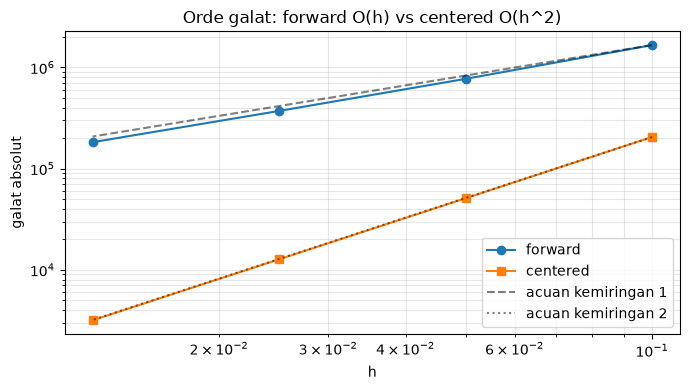

In [43]:
# --- Bukti orde galat: forward O(h) vs centered O(h^2) ---
# Acuan eksak = model eksponensial kanonik (turunan analitik diketahui)
E0c, ac = 1518928.89, 4.253735  # kanonik ( diverifikasi identik di sel regresi §3;
# orde hasil tak sensitif terhadap digit akhir)
S_mod = lambda e: E0c/ac*(np.exp(ac*e)-1)
D_mod = lambda e: E0c*np.exp(ac*e)
e0 = 0.35
hs = np.array([0.10, 0.05, 0.025, 0.0125])
err_fw = np.array([abs((S_mod(e0+h)-S_mod(e0))/h - D_mod(e0)) for h in hs])
err_ce = np.array([abs((S_mod(e0+h)-S_mod(e0-h))/(2*h) - D_mod(e0)) for h in hs])
print(f"{'h':>8} {'forward':>12} {'centered':>12}")
for h, ef, ec in zip(hs, err_fw, err_ce):
    print(f"{h:>8.4f} {ef:>12.2e} {ec:>12.2e}")
plt.figure(figsize=(7,4))
plt.loglog(hs, err_fw, 'o-', label='forward')
plt.loglog(hs, err_ce, 's-', label='centered')
plt.loglog(hs, hs*err_fw[0]/hs[0], 'k--', alpha=0.5, label='acuan kemiringan 1')
plt.loglog(hs, hs**2*err_ce[0]/hs[0]**2, 'k:', alpha=0.5, label='acuan kemiringan 2')
plt.xlabel('h'); plt.ylabel('galat absolut'); plt.title('Orde galat: forward O(h) vs centered O(h^2)')
plt.legend(); plt.grid(True, which='both', alpha=0.3); plt.tight_layout()
plt.savefig('orde_galat.png', dpi=130, bbox_inches='tight'); plt.show()


## 3. Regresi Kuadrat Terkecil — Menentukan $E_0$ dan $a$

Tiga metode independen untuk verifikasi silang:
1. **Manual Least-Squares**
2. **scipy.stats.linregress**
3. **numpy.polyfit**

Formula yang dipakai (model $y = a\,x + E_0$, $n=11$ titik $i=2..12$):

$$ a = \frac{n\Sigma x_i y_i - \Sigma x_i\Sigma y_i}{n\Sigma x_i^2 - (\Sigma x_i)^2}, \qquad E_0 = \bar{y} - a\bar{x}, \qquad R^2 = 1 - \frac{SS_{res}}{SS_{tot}} $$

dengan $SS_{res}=\Sigma(y_i-\hat{y}_i)^2$, $SS_{tot}=\Sigma(y_i-\bar{y})^2$, $\hat{y}_i = a\,x_i + E_0$.

Jumlah antara: $\Sigma x=13.297.600$, $\Sigma y\approx73.272.682{,}54$, $\Sigma xy\approx1{,}40994\times10^{14}$, $\Sigma x^2\approx2{,}83975\times10^{13}$.

| Hasil | Nilai |
|---|---|
| $a$ (slope) | $4{,}253735$ |
| $E_0$ (intersep) | $1.518.928{,}89\ \mathrm{N/m^2}$ |
| $R^2$ | $0{,}971782$ |


In [44]:
# Variabel: x=σ (N/m²), y=dσ/dε (N/m²), n=11, Σx=13.297.600, Σy≈73.272.682,54
n = len(x_reg)  # n = 11 (i=2..12)
sum_x, sum_y = np.sum(x_reg), np.sum(y_reg)  # Σx=13.297.600; Σy≈73.272.682,54
sum_xy, sum_x2 = np.sum(x_reg*y_reg), np.sum(x_reg**2)  # Σxy=140.993.640.664.145; Σx²=28.397.522.560.000
x_bar, y_bar = sum_x/n, sum_y/n  # x̄=1.208.872,7273; ȳ≈6.661.152,9583

# numerator=576.579.223.950.252; denominator=135.546.582.400.000
a_manual = (n*sum_xy - sum_x*sum_y)/(n*sum_x2 - sum_x**2)  # slope a ≈ 4,253735
E0_manual = y_bar - a_manual*x_bar  # intersep E₀ ≈ 1.518.928,89 N/m²

# y_pred=ŷᵢ=a·xᵢ+E₀; ss_res=Σ(yᵢ−ŷᵢ)²; ss_tot=Σ(yᵢ−ȳ)²; R²≈0,971782
y_pred = a_manual*x_reg + E0_manual
ss_res = np.sum((y_reg - y_pred)**2)
ss_tot = np.sum((y_reg - y_bar)**2)
r2_manual = 1 - ss_res/ss_tot

print(f"Manual: a={a_manual:.6f}  E0={E0_manual:,.2f}  R2={r2_manual:.6f}")
print(f"  Σx={sum_x:.0f}  Σy={sum_y:.0f}  Σxy={sum_xy:.2e}  Σx2={sum_x2:.2e}")
print(f"  x̄={x_bar:.2f}  ȳ={y_bar:.2f}")

# Verifikasi 2: slope=a, intercept=E₀, r_value=r, p_value=uji slope, std_err=galat baku
slope, intercept, r_val, p_val, std_err = stats.linregress(x_reg, y_reg)
print(f"\nlinregress: a={slope:.6f}  E0={intercept:,.2f}  R2={r_val**2:.6f}")

# Verifikasi 3: coeffs[0]=a, coeffs[1]=E₀
coeffs = np.polyfit(x_reg, y_reg, 1)
print(f"polyfit  : a={coeffs[0]:.6f}  E0={coeffs[1]:,.2f}")

# Catatan bias: fit di ruang turunan, jadi f(ε_data) di ruang σ−ε tetap besar;
# sisa dinilai via rel turunan (lihat sel 4.2), bukan |f| absolut.
E0, a = E0_manual, a_manual
print(f"\n>>> Konstanta: E0={E0:,.2f} N/m2, a={a:.6f}, R2={r2_manual:.6f}")


Manual: a=4.253735  E0=1,518,928.89  R2=0.971782
  Σx=13297600  Σy=73272683  Σxy=1.41e+14  Σx2=2.84e+13
  x̄=1208872.73  ȳ=6661152.96

linregress: a=4.253735  E0=1,518,928.89  R2=0.971782
polyfit  : a=4.253735  E0=1,518,928.89

>>> Konstanta: E0=1,518,928.89 N/m2, a=4.253735, R2=0.971782


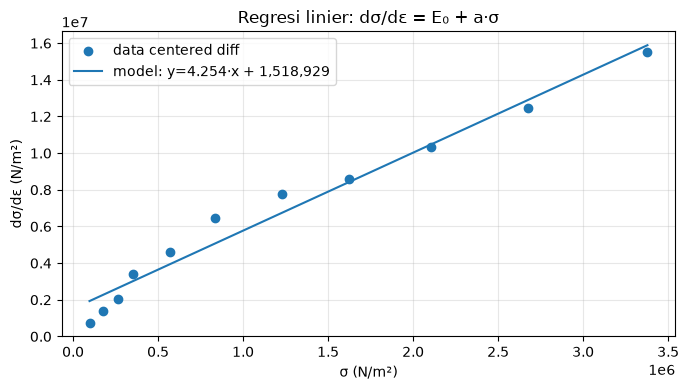

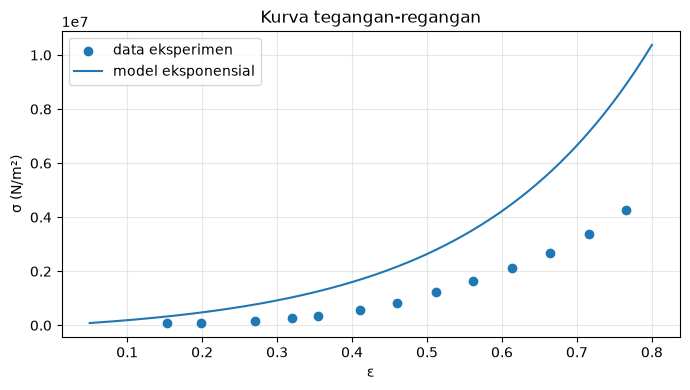

In [66]:
# Plot regresi + kurva model (label unicode, figsize seragam)
plt.figure(figsize=(7,4))
plt.scatter(x_reg, y_reg, label='data centered diff', zorder=3)
xx = np.linspace(x_reg.min(), x_reg.max(), 200)
plt.plot(xx, a*xx + E0, label=f'model: y={a:.3f}·x + {E0:,.0f}')
plt.xlabel('σ (N/m²)'); plt.ylabel('dσ/dε (N/m²)')
plt.title('Regresi linier: dσ/dε = E₀ + a·σ')
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout()
plt.savefig('regresi_linier.png', dpi=130, bbox_inches='tight'); plt.show()

plt.figure(figsize=(7,4))
plt.scatter(eps_all, sigma_all, label='data eksperimen', zorder=3)
eps_model = np.linspace(0.05, 0.80, 300)
sigma_model_curve = E0/a*(np.exp(a*eps_model)-1)
plt.plot(eps_model, sigma_model_curve, label='model eksponensial')
plt.xlabel('ε'); plt.ylabel('σ (N/m²)'); plt.title('Kurva tegangan-regangan')
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout()
plt.savefig('kurva_tegangan_regangan.png', dpi=130, bbox_inches='tight'); plt.show()


## 4. *Weighted Multi-Criteria Analysis* — Pemilihan $\sigma_{target}$ Optimal

Tujuan: memilih **satu** $\sigma_{target}$ dari 13 kandidat (tabel data) yang paling **mudah, stabil, dan representatif** untuk didemonstrasikan dengan metode terbuka (*open*) maupun tertutup (*bracketing*).

Empat langkah sesuai instruksi tugas:

| Langkah | Metode | Output |
|---------|--------|--------|
| **4.1** | *Inverse Model* (Analitik) | $\varepsilon_{exact}=\frac1a\ln\left(\frac{a\sigma}{E_0}+1\right)$ untuk tiap $\sigma$ |
| **4.2** | *Centered Finite Difference* cek | Bandingkan $y_{\mathrm{data}}$ vs $y_{\mathrm{model}}=E_0+a\sigma$ |
| **4.3** | *Sign-Change Root Detection* | Sapu $\varepsilon\in[0{,}001,0{,}85]$ cari $f(\varepsilon)$ ganti tanda (rentang lebar agar mencakup akar semua kandidat $0{,}05$–$0{,}60$) |
| **4.4** | *Weighted Scoring* (5 kriteria) | Skor 0/1 per kriteria × bobot → ranking |


In [46]:
# --- 4.1 Inverse Model (analitik): ε* = (1/a)·ln(a·σ/E₀ + 1) ---
def eps_exact(sigma, E0=E0, a=a):
    return (1/a)*np.log(a*sigma/E0 + 1)

def f_eps(eps, sigma_target, E0=E0, a=a):
    return E0/a*(np.exp(a*eps)-1) - sigma_target

def fp_eps(eps, E0=E0, a=a):
    return E0*np.exp(a*eps)  # = E₀ + a·σ

candidates = []
for i,(s,e) in enumerate(zip(sigma_all, eps_all), start=1):
    ee = eps_exact(s)
    candidates.append({"i": i, "sigma": s, "eps_data": e, "eps_exact": ee,
                           "eps_err": abs(e - ee), "fp": fp_eps(ee)})
    print(f"i={i:2d} sigma={s:8.0f}  eps_data={e:.3f}  eps_exact≈{ee:.6f}  err={abs(e-ee):.4f}  f'={fp_eps(ee):.0f}")

df_inv = pd.DataFrame(candidates)
print(df_inv.round(4).to_string(index=False))


i= 1 sigma=   87800  eps_data=0.153  eps_exact≈0.051683  err=0.1013  f'=1892407
i= 2 sigma=   96600  eps_data=0.198  eps_exact≈0.056287  err=0.1417  f'=1929840
i= 3 sigma=  176000  eps_data=0.270  eps_exact≈0.094202  err=0.1758  f'=2267586
i= 4 sigma=  263000  eps_data=0.320  eps_exact≈0.129742  err=0.1903  f'=2637661
i= 5 sigma=  350000  eps_data=0.355  eps_exact≈0.160608  err=0.1944  f'=3007736
i= 6 sigma=  569000  eps_data=0.410  eps_exact≈0.224038  err=0.1860  f'=3939304
i= 7 sigma=  833000  eps_data=0.460  eps_exact≈0.283002  err=0.1770  f'=5062290
i= 8 sigma= 1227000  eps_data=0.512  eps_exact≈0.350233  err=0.1618  f'=6738262
i= 9 sigma= 1623000  eps_data=0.562  eps_exact≈0.402688  err=0.1593  f'=8422741
i=10 sigma= 2105000  eps_data=0.614  eps_exact≈0.453907  err=0.1601  f'=10473041
i=11 sigma= 2677000  eps_data=0.664  eps_exact≈0.503017  err=0.1610  f'=12906177
i=12 sigma= 3378000  eps_data=0.716  eps_exact≈0.551882  err=0.1641  f'=15888045
i=13 sigma= 4257000  eps_data=0.766  

In [47]:
# --- 4.2 Centered Finite Difference — cek konsistensi ---
# y_model = E₀ + a·σ. y_data via y_by_i (aman, tanpa offset y_num[i-1]).
# Catatan bias: f(ε_data) besar sistematis (i=8: +1.568.181, 127%) karena fit
# di ruang turunan. Sisa dinilai via rel turunan, bukan |f| absolut.
print(f"{'i':>2} {'sigma':>8} {'y_data':>10} {'y_model':>10} {'rel_err':>8} {'f(eps_data)':>12}")
for i,(s,e) in enumerate(zip(sigma_all, eps_all), start=1):
    y_model = E0 + a*s
    if i in y_by_i:
        y_data = y_by_i[i]
        rel = abs(y_data - y_model)/y_model
        print(f"{i:2d} {s:8.0f} {y_data:10.0f} {y_model:10.0f} {rel:7.2%} {f_eps(e,s):12.0f}")
    else:  # boundary i=1,13 tanpa y_data
        print(f"{i:2d} {s:8.0f} {'-':>10} {E0 + a*s:10.0f} {'-':>8} {f_eps(e,s):12.0f}")


 i    sigma     y_data    y_model  rel_err  f(eps_data)
 1    87800          -    1892407        -       239685
 2    96600     753846    1929840  60.94%       375304
 3   176000    1363934    2267586  39.85%       592969
 4   263000    2047059    2637661  22.39%       772840
 5   350000    3400000    3007736  13.04%       909452
 6   569000    4600000    3939304  16.77%      1116551
 7   833000    6450980    5062290  27.43%      1336649
 8  1227000    7745098    6738262  14.94%      1568181
 9  1623000    8607843    8422741   2.20%      1919258
10  2105000   10333333   10473041   1.33%      2402600
11  2677000   12480392   12906177   3.30%      2983516
12  3378000   15490196   15888045   2.50%      3772266
13  4257000          -   19627078        -      4672486


Deteksi pergantian tanda f(ε) pada interval [0,001, 0,85]:
 i     sigma   f(0,001)      f(0,85) sign_change  eps_cross
 1     87800     -86278     12830120        True 0.05168223965184985
 2     96600     -95078     12821320        True 0.05628728360599678
 3    176000    -174478     12741920        True 0.09420170424809764
 4    263000    -261478     12654920        True 0.12974141013248894
 5    350000    -348478     12567920        True 0.16060738679103542
 6    569000    -567478     12348920        True 0.22403771622371157
 7    833000    -831478     12084920        True 0.2830013256957704
 8   1227000   -1225478     11690920        True 0.35023249066789347
 9   1623000   -1621478     11294920        True 0.4026880931225701
10   2105000   -2103478     10812920        True 0.45390665246072903
11   2677000   -2675478     10240920        True 0.5030166112697934
12   3378000   -3376478      9539920        True 0.5518821773552022
13   4257000   -4255478      8660920        True 0.601566

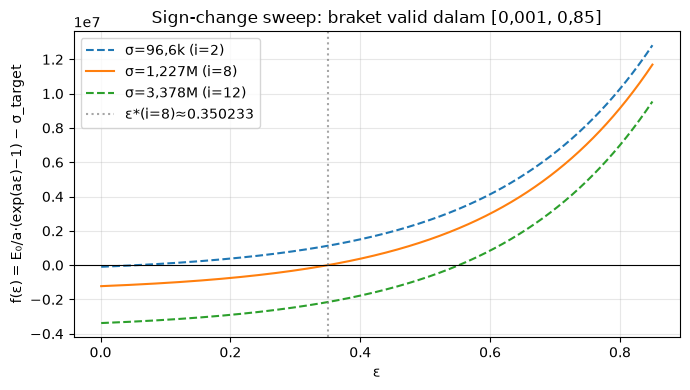

In [67]:
# --- 4.3 Sign-Change Root Detection: sapu ε 0,001–0,85 (1000 titik) ---
eps_sweep = np.linspace(0.001, 0.85, 1000)

print("Deteksi pergantian tanda f(ε) pada interval [0,001, 0,85]:")
print(f"{'i':>2} {'sigma':>9} {'f(0,001)':>10} {'f(0,85)':>12} {'sign_change':>11} {'eps_cross':>10}")
for c in candidates:
    s = c['sigma']
    f_vals = f_eps(eps_sweep, s)
    f_a, f_b = f_vals[0], f_vals[-1]
    has_cross = f_a*f_b < 0
    cross = None
    idx = np.where(np.sign(f_vals[:-1]) != np.sign(f_vals[1:]))[0]
    if len(idx)>0:  # interpolasi linier kasar di crossing pertama
        j = idx[0]
        cross = eps_sweep[j] - f_vals[j]*(eps_sweep[j+1]-eps_sweep[j])/(f_vals[j+1]-f_vals[j])
    print(f"{c['i']:2d} {s:9.0f} {f_a:10.0f} {f_b:12.0f} {has_cross!s:>11} {cross if cross else '-':>10}")

# Visualisasi 3 wakil: kecil (i=2), tengah (i=8), besar (i=12)
eps_star_i8 = candidates[7]['eps_exact']
plt.figure(figsize=(7,4))
for s_plot, lab, ls in [(96600,'σ=96,6k (i=2)','--'), (1227000,'σ=1,227M (i=8)','-'), (3378000,'σ=3,378M (i=12)','--')]:
    plt.plot(eps_sweep, f_eps(eps_sweep, s_plot), label=lab, ls=ls)
plt.axhline(0, color='k', lw=0.8); plt.axvline(eps_star_i8, color='gray', ls=':', alpha=0.7, label=f'ε*(i=8)≈{eps_star_i8:.6f}')
plt.xlabel('ε'); plt.ylabel('f(ε) = E₀/a·(exp(aε)−1) − σ_target')
plt.title('Sign-change sweep: braket valid dalam [0,001, 0,85]')
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout()
plt.savefig('sign_change_sweep.png', dpi=130, bbox_inches='tight'); plt.show()


### 4.4 *Weighted Scoring* — 5 Kriteria

Setiap kandidat $\sigma_i$ diberi skor biner $0/1$ per kriteria, lalu dikalikan bobot $w_k$ dan dijumlahkan:

$$ S_i = \sum_{k=1}^{5} w_k \cdot C_{k,i}, \qquad \sum w_k = 1 $$

| Kriteria | Bobot | Definisi (skor 1 jika memenuhi) | Rasional Numerik |
|----------|-------|----------------------------------|------------------|
| **K1** Validitas Braket | **0.25** | $f(0{,}001)\cdot f(0{,}85)<0$ (ada pergantian tanda) | Syarat mutlak metode tertutup (*bisection*, *false-position*, *Brent*) |
| **K2** Sentralitas Akar | **0.20** | $0{,}20 \le \varepsilon_{\mathrm{exact}} \le 0{,}40$ | Tidak terlalu dekat batas → iterasi stabil, visualisasi jelas |
| **K3** Kondisi Turunan | **0.25** | $4\times10^6 \le f'(\varepsilon_{\mathrm{exact}}) \le 8\times10^6$ | $f'$ tidak terlalu landai (Newton lambat) maupun curam (galat besar) |
| **K4** Konsistensi Turunan | **0.15** | $\frac{\left\vert y_{\mathrm{data}}-y_{\mathrm{model}}\right\vert}{y_{\mathrm{model}}} < 0{,}20$ (untuk $i=2,\dots,12$) | Konsisten model-data di ruang fit → bukan *outlier* |
| **K5** Kedekatan Invers | **0.15** | $\left\vert\varepsilon_{\mathrm{data}}-\varepsilon_{\mathrm{exact}}\right\vert < 0{,}18$ | Galat posisi moderat, representatif |

> Batas K2–K3 diambil dari sebaran tengah kandidat agar contoh ajar sentral dan *well-conditioned*.


 i   sigma  eps_exact      f_prime  K1  K2  K3  K4  K5  skor_biner  skor_terbobot
 1   87800   0.051683 1.892407e+06   1   0   0   0   1           2           0.40
 2   96600   0.056287 1.929840e+06   1   0   0   0   1           2           0.40
 3  176000   0.094202 2.267586e+06   1   0   0   0   1           2           0.40
 4  263000   0.129742 2.637661e+06   1   0   0   0   0           1           0.25
 5  350000   0.160608 3.007736e+06   1   0   0   1   0           2           0.40
 6  569000   0.224038 3.939304e+06   1   1   0   1   0           3           0.60
 7  833000   0.283002 5.062290e+06   1   1   1   0   1           4           0.85
 8 1227000   0.350233 6.738262e+06   1   1   1   1   1           5           1.00
 9 1623000   0.402688 8.422741e+06   1   0   0   1   1           3           0.55
10 2105000   0.453907 1.047304e+07   1   0   0   1   1           3           0.55
11 2677000   0.503017 1.290618e+07   1   0   0   1   1           3           0.55
12 3378000   0.5

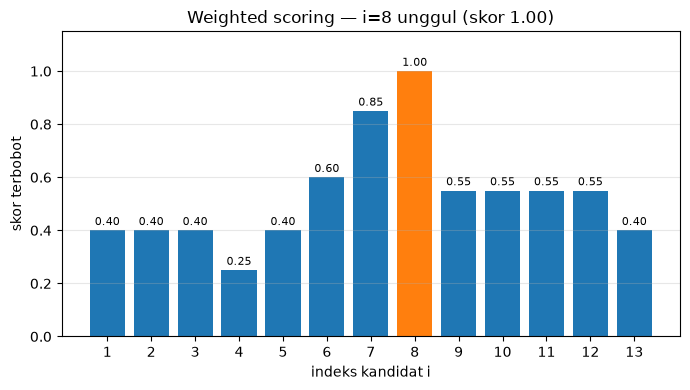

In [49]:
# --- Hitung skor 0/1 per kriteria (K1–K5) ---
weights = {'K1':0.25, 'K2':0.20, 'K3':0.25, 'K4':0.15, 'K5':0.15}

rows = []
for c in candidates:
    i = c['i']; s=c['sigma']; ee=c['eps_exact']; fp=c['fp']; ed=c['eps_data']
    f_a = f_eps(0.001, s); f_b = f_eps(0.85, s)
    K1 = 1 if f_a*f_b < 0 else 0  # braket valid
    K2 = 1 if 0.20 <= ee <= 0.40 else 0  # sentral
    K3 = 1 if 4e6 <= fp <= 8e6 else 0  # well-conditioned
    if i in y_by_i:  # K4: konsistensi turunan <0,20
        rel = abs(y_by_i[i]-(E0 + a*s))/(E0 + a*s)
        K4 = 1 if rel < 0.20 else 0
    else:
        K4 = 0  # boundary tanpa y_data
    K5 = 1 if abs(ed - ee) < 0.18 else 0
    weighted = weights['K1']*K1 + weights['K2']*K2 + weights['K3']*K3 + weights['K4']*K4 + weights['K5']*K5
    rows.append([i, s, ee, fp, K1,K2,K3,K4,K5, K1+K2+K3+K4+K5, weighted])

df_score = pd.DataFrame(rows, columns=['i','sigma','eps_exact','f_prime','K1','K2','K3','K4','K5','skor_biner','skor_terbobot'])
df_score['sigma'] = df_score['sigma'].astype(int)
df_rank = df_score.sort_values(['skor_terbobot','skor_biner','i'], ascending=[False, False, True])
print(df_score.to_string(index=False))
print("\n=== RANKING ===")
print(df_rank.to_string(index=False))

winner = df_rank.iloc[0]
print(f"\n>>> PEMENANG: i={int(winner['i'])}  sigma={int(winner['sigma'])} N/m2  eps_exact≈{winner['eps_exact']:.6f}  skor={winner['skor_terbobot']:.2f} ({int(winner['skor_biner'])}/5)")

win_i = int(winner['i'])
plt.figure(figsize=(7,4))
plt.bar(df_score['i'], df_score['skor_terbobot'], color=['C1' if i==win_i else 'C0' for i in df_score['i']])
plt.xticks(df_score['i']); plt.xlabel('indeks kandidat i'); plt.ylabel('skor terbobot')
plt.title(f'Weighted scoring — i={win_i} unggul (skor {winner["skor_terbobot"]:.2f})')
for _,r in df_score.iterrows():
    plt.text(r['i'], r['skor_terbobot']+0.02, f"{r['skor_terbobot']:.2f}", ha='center', fontsize=8)
plt.ylim(0,1.15); plt.grid(axis='y', alpha=0.3); plt.tight_layout(); plt.show()


In [50]:
# Rincian K4 (rel_err turunan) — memakai y_by_i yang sama dengan sel scoring
print("Rincian K4 (rel_err turunan):")
for c in candidates:
    i=c['i']; s=c['sigma']
    if i in y_by_i:
        rel=abs(y_by_i[i]-(E0+a*s))/(E0+a*s)
        print(f" i={i:2d} rel={rel:.3f} -> K4={1 if rel<0.20 else 0}")
    else:
        print(f" i={i:2d} boundary -> K4=0")


Rincian K4 (rel_err turunan):
 i= 1 boundary -> K4=0
 i= 2 rel=0.609 -> K4=0
 i= 3 rel=0.399 -> K4=0
 i= 4 rel=0.224 -> K4=0
 i= 5 rel=0.130 -> K4=1
 i= 6 rel=0.168 -> K4=1
 i= 7 rel=0.274 -> K4=0
 i= 8 rel=0.149 -> K4=1
 i= 9 rel=0.022 -> K4=1
 i=10 rel=0.013 -> K4=1
 i=11 rel=0.033 -> K4=1
 i=12 rel=0.025 -> K4=1
 i=13 boundary -> K4=0


#### Interpretasi Hasil

- **K1** semua kandidat lolos (braket valid) — dengan $E_0\approx1{,}52\times10^6$, semua $\varepsilon_{\mathrm{exact}}<0{,}85$ sehingga $f(0{,}001)<0<f(0{,}85)$.
- **K2** hanya $i=6,7,8$ yang sentral ($0{,}20$–$0{,}40$) — $i=8$ ($\varepsilon\approx0{,}350233$) di tengah, ideal ilustrasi. ($i=9$ di $0{,}4027$, sedikit di luar batas.)
- **K3** hanya $i=7$ ($5{,}06\times10^6$) dan $i=8$ ($6{,}74\times10^6$) yang *well-conditioned*.
- **K4** $i=8$ lolos ($rel=0{,}149<0{,}20$) sedangkan $i=7$ gagal ($0{,}274$) — $i=8$ lebih konsisten model.
- **K5** titik tengah lolos, $i=4$, $5$, $6$ gagal karena galat invers besar.

**Total:** $i=8$ satu-satunya **5/5** ($S=1.00$); $i=7$ berikutnya $4/5$ ($0.85$); $i=6,9,10,11,12$ di $0.55$–$0.60$. Jadi **$\sigma_{target}=1\,227\,000\,\mathrm{N/m^2}$ (titik $i=8$, $\varepsilon_{\mathrm{data}}=0{,}512$, $\varepsilon_{\mathrm{exact}}\approx0{,}350233$)** terbaik

> **Catatan sisa (penting):** $f(\varepsilon_{\mathrm{data}})=+1\,568\,181$ (127%) tampak besar karena regresi difit di ruang turunan $d\sigma/d\varepsilon$, bukan ruang $\sigma$–$\varepsilon$ — gap $0{,}16$ sistematis semua titik, bukan outlier $i=8$. Sisa dinilai via rel turunan (K4), bukan $|f|$ absolut. Akar tetap sah $f(\varepsilon^*)=0$ dan braket valid. Nilai penuh $0{,}3502326\ldots$; digit ke-7 ikut pembulatan $E_0$, jadi ditampilkan $6$ desimal.


## 5. Demonstrasi Metode Pencarian Akar dengan $\sigma_{target}$ Terpilih

Gunakan konstanta hasil regresi dan $\sigma_{target}=1\,227\,000$:

$$ f(\varepsilon)=\frac{1\,518\,928{,}89}{4{,}253735}(e^{4{,}253735\varepsilon}-1)-1\,227\,000 $$

Substitusi $E_0$, $a$, $\sigma_{target}$ ke rumus invers $\varepsilon^*=(1/a)\ln(a\sigma/E_0+1)$:

$$ \varepsilon_{\mathrm{exact}}=\frac{1}{4{,}253735}\ln\left(\frac{4{,}253735\times1\,227\,000}{1\,518\,928{,}89}+1\right) $$

$$ =\frac{1}{4{,}253735}\ln\left(3{,}436193+1\right)=\frac{1{,}489797}{4{,}253735}\approx0{,}350233 $$

Kunci: $f(0{,}350233)\approx0$ — sah sebagai akar.


In [51]:
# --- 5.0 Adapter demo: konstanta kanonik main + spesifikasi seragam ---
# Ea=1e-5, maxit=50 (md: Kriteria Penghentian); braket tertutup [0,1; 0,6]
sigma_target = 1227000  # winner §4 (i=8)
TOL = 1e-5
MAX_IT = 50
E0_sel, a_sel = E0, a  # alias kanonik E0=1.518.928,89; a=4,253735
try:
    from tabulate import tabulate
    HAS_TABULATE = True
except ImportError:
    HAS_TABULATE = False

def f(eps): return E0_sel/a_sel*(np.exp(a_sel*eps)-1) - sigma_target
def fp(eps): return E0_sel*np.exp(a_sel*eps)
def fpp(eps): return E0_sel*a_sel*np.exp(a_sel*eps)
eps_star = float(eps_exact(sigma_target))  # fungsi eps_exact dari sel 4.1
print(f"sigma_target={sigma_target}  eps_exact≈{eps_star:.6f}  f(eps_star)={f(eps_star):.2e}")
print(f"f'(eps_star)={fp(eps_star):.2f}  f''(eps_star)={fpp(eps_star):.2f}")
print(f"Braket [0,1;0,6]: f(0,1)={f(0.1):.0f}  f(0,6)={f(0.6):.0f}  valid={f(0.1)*f(0.6)<0}")


sigma_target=1227000  eps_exact≈0.350233  f(eps_star)=0.00e+00
f'(eps_star)=6738261.57  f''(eps_star)=28662778.20
Braket [0,1;0,6]: f(0,1)=-1037689  f(0,6)=2999355  valid=True


### 5.0 Spesifikasi Demo

Tebakan awal metode terbuka $\varepsilon_0=0{,}01$ ($\varepsilon_1=0{,}05$ untuk secant); metode tertutup/hibrida pada braket $[0{,}1,0{,}6]$ (disempitkan karena akar $\sigma$ terpilih sudah diketahui sentral); kriteria berhenti $e_a<10^{-5}$, $maxit=50$. Semua metode memakai $f/f'/f''$ dari sel adapter.


---
### 5.1 Open Methods (Metode Terbuka)

| Metode | Tebakan awal / Braket | Orde konvergensi |
|--------|-------------|-----------------|
| Fixed-Point Iteration | eps0 = 0.01 | Linear |
| Newton-Raphson | eps0 = 0.01 | Kuadratik |
| Modified Newton-Raphson | eps0 = 0.01 | Kuadratik |
| Secant | eps0=0.01, eps1=0.05 | Superlinear (~1.618) |
| Modified Secant | eps0=0.01, delta=0.01 | Superlinear |
| Brent's Method | [0.1, 0.6] | Superlinear + Bisection |


#### 5.1.1 Fixed-Point Iteration

Persamaan $f(\varepsilon)=0$ diubah ke bentuk $\varepsilon = g(\varepsilon)$ dengan skema relaksasi:

$$\varepsilon_{n+1} = g(\varepsilon_n) = \varepsilon_n - \alpha\,f(\varepsilon_n), \quad \alpha = \frac{1}{f'(\varepsilon_{mid})}$$

di mana $\varepsilon_{mid} = 0.35\ \text{m/m}$ (titik tengah braket) digunakan agar syarat konvergensi $|g'(\varepsilon)| < 1$ terpenuhi.

> **Catatan:** Bila $\alpha = 1/f'(\varepsilon_0)$ dengan $\varepsilon_0 = 0.01$, maka $\alpha$ terlalu kecil dan iterasi divergen karena $f'$ tumbuh sangat cepat. Pemilihan $\alpha$ dari titik tengah menstabilkan konvergensi.


In [53]:
def fixed_point(eps0=0.01, tol=TOL, max_iter=MAX_IT):
    """
    Fixed-Point Iteration: eps_{n+1} = g(eps_n)
    Relaksasi: g(eps) = eps - alpha*f(eps), alpha = 1/f'(eps_mid),
    eps_mid = titik tengah braket [0,1; 0,6] agar |g'(eps)| < 1.
    """
    # Gunakan alpha dari titik mendekati solusi agar konvergen
    # alpha = 1/f'(eps_mid) dengan eps_mid = nilai tengah braket
    eps_mid = (0.1 + 0.6) / 2
    alpha   = 1.0 / fp(eps_mid)

    eps    = eps0
    hist   = [eps]
    errors = []
    err    = float('inf')
    for i in range(max_iter):
        eps_new = eps - alpha * f(eps)
        # clamp agar tidak keluar rentang fisik
        eps_new = max(0.001, min(0.85, eps_new))
        err     = abs(eps_new - eps)
        errors.append(err)
        hist.append(eps_new)
        eps = eps_new
        if err < tol:
            break
    return {'root': eps, 'iterations': i+1, 'history': hist,
            'errors': errors, 'converged': err < tol}

res_fpi = fixed_point()
print("Fixed-Point Iteration")
print(f"  Akar: eps = {res_fpi['root']:.10f} m/m")
print(f"  f(eps) = {f(res_fpi['root']):.4e}")
print(f"  Iterasi: {res_fpi['iterations']}  |  Error: {res_fpi['errors'][-1]:.4e}")
print(f"  Konvergen: {res_fpi['converged']}")


Fixed-Point Iteration
  Akar: eps = 0.3502325848 m/m
  f(eps) = -1.6905e-04
  Iterasi: 6  |  Error: 2.5369e-08
  Konvergen: True


#### 5.1.2 Newton-Raphson Method

$$\varepsilon_{n+1} = \varepsilon_n - \frac{f(\varepsilon_n)}{f'(\varepsilon_n)}, \quad f'(\varepsilon) = E_0\,e^{a\varepsilon}$$


In [54]:
def newton_raphson(eps0=0.01, tol=TOL, max_iter=MAX_IT):
    eps    = eps0
    hist   = [eps]
    errors = []
    err    = float('inf')
    for i in range(max_iter):
        fv  = f(eps)
        fpv = fp(eps)
        if abs(fpv) < 1e-30:
            break
        eps_new = eps - fv / fpv
        err     = abs(eps_new - eps)
        errors.append(err)
        hist.append(eps_new)
        eps = eps_new
        if err < tol:
            break
    return {'root': eps, 'iterations': i+1, 'history': hist,
            'errors': errors, 'converged': err < tol}

res_nr = newton_raphson()
print("Newton-Raphson Method")
print(f"  Akar: eps = {res_nr['root']:.10f} m/m")
print(f"  f(eps) = {f(res_nr['root']):.4e}")
print(f"  Iterasi: {res_nr['iterations']}  |  Error: {res_nr['errors'][-1]:.4e}")


Newton-Raphson Method
  Akar: eps = 0.3502325848 m/m
  f(eps) = 8.5635e-07
  Iterasi: 7  |  Error: 2.4447e-07


#### 5.1.3 Modified Newton-Raphson (Akar Berganda)

$$\varepsilon_{n+1} = \varepsilon_n - \frac{f(\varepsilon_n)\,f'(\varepsilon_n)}{[f'(\varepsilon_n)]^2 - f(\varepsilon_n)\,f''(\varepsilon_n)}$$


In [55]:
def modified_newton_raphson(eps0=0.01, tol=TOL, max_iter=MAX_IT):
    eps    = eps0
    hist   = [eps]
    errors = []
    err    = float('inf')
    for i in range(max_iter):
        fv   = f(eps)
        fpv  = fp(eps)
        fppv = fpp(eps)
        denom = fpv**2 - fv * fppv
        if abs(denom) < 1e-30:
            break
        eps_new = eps - (fv * fpv) / denom
        err     = abs(eps_new - eps)
        errors.append(err)
        hist.append(eps_new)
        eps = eps_new
        if err < tol:
            break
    return {'root': eps, 'iterations': i+1, 'history': hist,
            'errors': errors, 'converged': err < tol}

res_mnr = modified_newton_raphson()
print("Modified Newton-Raphson")
print(f"  Akar: eps = {res_mnr['root']:.10f} m/m")
print(f"  f(eps) = {f(res_mnr['root']):.4e}")
print(f"  Iterasi: {res_mnr['iterations']}  |  Error: {res_mnr['errors'][-1]:.4e}")


Modified Newton-Raphson
  Akar: eps = 0.3502325848 m/m
  f(eps) = -2.3283e-10
  Iterasi: 6  |  Error: 2.1999e-09


#### 5.1.4 Secant Method

$$\varepsilon_{i+1} = \varepsilon_i - \frac{f(\varepsilon_i)\,(\varepsilon_{i-1} - \varepsilon_i)}{f(\varepsilon_{i-1}) - f(\varepsilon_i)}$$


In [56]:
def secant(eps0=0.01, eps1=0.05, tol=TOL, max_iter=MAX_IT):
    hist   = [eps0, eps1]
    errors = []
    err    = float('inf')
    for i in range(max_iter):
        f0 = f(eps0); f1 = f(eps1)
        if abs(f1 - f0) < 1e-30:
            break
        eps_new = eps1 - f1 * (eps0 - eps1) / (f0 - f1)
        err     = abs(eps_new - eps1)
        errors.append(err)
        hist.append(eps_new)
        eps0, eps1 = eps1, eps_new
        if err < tol:
            break
    return {'root': eps1, 'iterations': i+1, 'history': hist,
            'errors': errors, 'converged': err < tol}

res_sec = secant()
print("Secant Method")
print(f"  Akar: eps = {res_sec['root']:.10f} m/m")
print(f"  f(eps) = {f(res_sec['root']):.4e}")
print(f"  Iterasi: {res_sec['iterations']}  |  Error: {res_sec['errors'][-1]:.4e}")


Secant Method
  Akar: eps = 0.3502325848 m/m
  f(eps) = -2.4375e-04
  Iterasi: 9  |  Error: 2.6401e-07


#### 5.1.5 Modified Secant Method

$$\varepsilon_{n+1} = \varepsilon_n - \frac{\delta\,\varepsilon_n \cdot f(\varepsilon_n)}{f(\varepsilon_n + \delta\,\varepsilon_n) - f(\varepsilon_n)}$$


In [57]:
def modified_secant(eps0=0.01, delta=0.01, tol=TOL, max_iter=MAX_IT):
    eps    = eps0
    hist   = [eps]
    errors = []
    err    = float('inf')
    for i in range(max_iter):
        fv     = f(eps)
        f_pert = f(eps + delta * eps)
        denom  = f_pert - fv
        if abs(denom) < 1e-30:
            break
        eps_new = eps - (delta * eps * fv) / denom
        err     = abs(eps_new - eps)
        errors.append(err)
        hist.append(eps_new)
        eps = eps_new
        if err < tol:
            break
    return {'root': eps, 'iterations': i+1, 'history': hist,
            'errors': errors, 'converged': err < tol}

res_msec = modified_secant()
print("Modified Secant Method")
print(f"  Akar: eps = {res_msec['root']:.10f} m/m")
print(f"  f(eps) = {f(res_msec['root']):.4e}")
print(f"  Iterasi: {res_msec['iterations']}  |  Error: {res_msec['errors'][-1]:.4e}")


Modified Secant Method
  Akar: eps = 0.3502326199 m/m
  f(eps) = 2.3641e-01
  Iterasi: 7  |  Error: 4.6803e-06


#### 5.1.6 Brent's Method

Menggabungkan **Bisection + Secant + Inverse Quadratic Interpolation**.
Selalu konvergen (seperti bisection) sekaligus cepat (seperti IQI/secant).


In [58]:
def brents_method(a_b=0.1, b_b=0.6, tol=TOL, max_iter=MAX_IT):
    fa, fb = f(a_b), f(b_b)
    if fa * fb > 0:
        raise ValueError("f(a) dan f(b) harus berlawanan tanda.")
    if abs(fa) < abs(fb):
        a_b, b_b = b_b, a_b
        fa, fb   = fb, fa
    c, fc  = a_b, fa
    mflag  = True
    s = d  = 0.0
    hist   = [b_b]
    errors = []
    err    = float('inf')
    for i in range(max_iter):
        if fa != fc and fb != fc:
            s = (a_b*fb*fc/((fa-fb)*(fa-fc)) +
                 b_b*fa*fc/((fb-fa)*(fb-fc)) +
                 c  *fa*fb/((fc-fa)*(fc-fb)))
        else:
            s = b_b - fb*(b_b-a_b)/(fb-fa)
        c1 = not ((3*a_b+b_b)/4 < s < b_b or b_b < s < (3*a_b+b_b)/4)
        c2 = mflag     and abs(s-b_b) >= abs(b_b-c)/2
        c3 = not mflag and abs(s-b_b) >= abs(c-d)/2
        c4 = mflag     and abs(b_b-c) < tol
        c5 = not mflag and abs(c-d)   < tol
        if c1 or c2 or c3 or c4 or c5:
            s = (a_b + b_b) / 2
            mflag = True
        else:
            mflag = False
        fs = f(s); d = c; c = b_b; fc = fb
        if fa * fs < 0:
            b_b = s; fb = fs
        else:
            a_b = s; fa = fs
        if abs(fa) < abs(fb):
            a_b, b_b = b_b, a_b
            fa, fb   = fb, fa
        err = abs(b_b - a_b)
        errors.append(err)
        hist.append(b_b)
        if err < tol or abs(fb) < 1e-14:
            break
    return {'root': b_b, 'iterations': i+1, 'history': hist,
            'errors': errors, 'converged': err < tol}

res_brent = brents_method()
print("Brent's Method")
print(f"  Akar: eps = {res_brent['root']:.10f} m/m")
print(f"  f(eps) = {f(res_brent['root']):.4e}")
print(f"  Iterasi: {res_brent['iterations']}  |  Error: {res_brent['errors'][-1]:.4e}")


Brent's Method
  Akar: eps = 0.3502325706 m/m
  f(eps) = -9.5410e-02
  Iterasi: 6  |  Error: 5.0017e-06


---
### 5.2 Bracketing Methods (Metode Pengapitan)

Braket yang digunakan: **[0.1, 0.6]**  
f(0.1) < 0 dan f(0.6) > 0 — berlawanan tanda ✓


#### 5.2.1 Graphical Approach

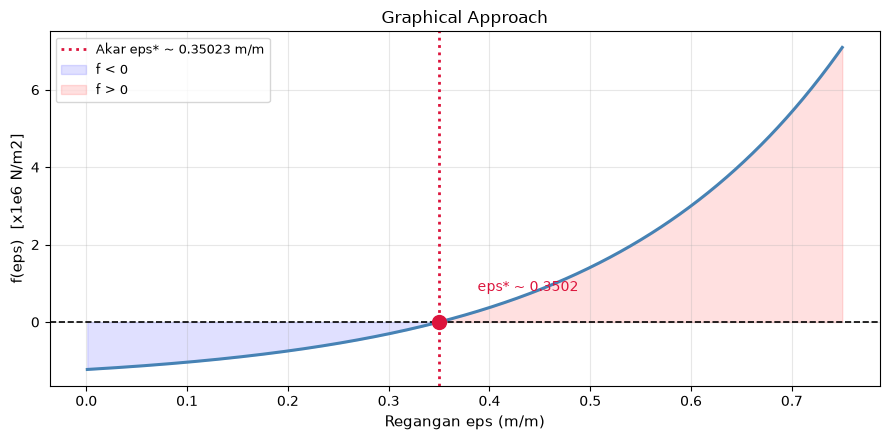

Akar terbaca grafis: eps* ~ 0.3502 m/m


In [59]:
eps_g = np.linspace(0.001, 0.75, 800)
f_g   = f(eps_g)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(eps_g, f_g/1e6, 'steelblue', lw=2.2)
ax.axhline(0, color='k', lw=1.2, ls='--')
ax.axvline(eps_star, color='crimson', lw=2, ls=':',
           label=f'Akar eps* ~ {eps_star:.5f} m/m')
ax.fill_between(eps_g, f_g/1e6, 0, where=(f_g<0), alpha=0.12, color='blue',  label='f < 0')
ax.fill_between(eps_g, f_g/1e6, 0, where=(f_g>0), alpha=0.12, color='red',   label='f > 0')
ax.plot(eps_star, 0, 'o', color='crimson', ms=10, zorder=5)
ax.annotate(f'  eps* ~ {eps_star:.4f}',
            xy=(eps_star, 0), fontsize=10, color='crimson', xytext=(eps_star+0.03, 0.8))
ax.set_xlabel('Regangan eps (m/m)', fontsize=11)
ax.set_ylabel('f(eps)  [x1e6 N/m2]', fontsize=11)
ax.set_title('Graphical Approach', fontsize=12)
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('graphical.png', dpi=130, bbox_inches='tight')
plt.show()
print(f"Akar terbaca grafis: eps* ~ {eps_star:.4f} m/m")


#### 5.2.2 Bisection Method

$$\varepsilon_{mid} = \frac{\varepsilon_{lo} + \varepsilon_{hi}}{2}$$


In [60]:
def bisection(lo=0.1, hi=0.6, tol=TOL, max_iter=MAX_IT):
    flo    = f(lo)
    hist   = []
    errors = []
    err    = float('inf')
    for i in range(max_iter):
        mid  = (lo + hi) / 2.0
        fmid = f(mid)
        err  = abs(hi - lo) / 2.0
        hist.append(mid)
        errors.append(err)
        if flo * fmid < 0:
            hi = mid
        else:
            lo = mid; flo = fmid
        if err < tol:
            break
    return {'root': mid, 'iterations': i+1, 'history': hist,
            'errors': errors, 'converged': err < tol}

res_bis = bisection()
print("Bisection Method")
print(f"  Akar: eps = {res_bis['root']:.10f} m/m")
print(f"  f(eps) = {f(res_bis['root']):.4e}")
print(f"  Iterasi: {res_bis['iterations']}  |  Error: {res_bis['errors'][-1]:.4e}")


Bisection Method
  Akar: eps = 0.3502365112 m/m
  f(eps) = 2.6458e+01
  Iterasi: 16  |  Error: 7.6294e-06


#### 5.2.3 False-Position Method (*Regula Falsi*)

$$\varepsilon_r = \varepsilon_{hi} - \frac{f(\varepsilon_{hi})(\varepsilon_{lo} - \varepsilon_{hi})}{f(\varepsilon_{lo}) - f(\varepsilon_{hi})}$$


In [61]:
def false_position(lo=0.1, hi=0.6, tol=TOL, max_iter=MAX_IT):
    flo       = f(lo); fhi = f(hi)
    eps_r_old = lo
    hist      = []
    errors    = []
    err       = float('inf')
    for i in range(max_iter):
        eps_r = hi - fhi * (lo - hi) / (flo - fhi)
        fr    = f(eps_r)
        err   = abs(eps_r - eps_r_old)
        hist.append(eps_r)
        errors.append(err)
        if flo * fr < 0:
            hi  = eps_r; fhi = fr
        else:
            lo  = eps_r; flo = fr
        eps_r_old = eps_r
        if i > 0 and err < tol:
            break
    return {'root': eps_r, 'iterations': i+1, 'history': hist,
            'errors': errors, 'converged': err < tol}

res_fp = false_position()
print("False-Position Method")
print(f"  Akar: eps = {res_fp['root']:.10f} m/m")
print(f"  f(eps) = {f(res_fp['root']):.4e}")
print(f"  Iterasi: {res_fp['iterations']}  |  Error: {res_fp['errors'][-1]:.4e}")


False-Position Method
  Akar: eps = 0.3502257087 m/m
  f(eps) = -4.6332e+01
  Iterasi: 13  |  Error: 8.7911e-06


---
### 5.3 Tabel Perbandingan Semua Metode

In [62]:
results_all = {
    'Fixed-Point Iter.': res_fpi,
    'Newton-Raphson'   : res_nr,
    'Modified NR'      : res_mnr,
    'Secant'           : res_sec,
    'Modified Secant'  : res_msec,
    "Brent's"          : res_brent,
    'Bisection'        : res_bis,
    'False-Position'   : res_fp,
}
categories = {
    'Fixed-Point Iter.': 'Open',
    'Newton-Raphson'   : 'Open',
    'Modified NR'      : 'Open',
    'Secant'           : 'Open',
    'Modified Secant'  : 'Open',
    "Brent's"          : 'Open+Bracket',
    'Bisection'        : 'Bracketing',
    'False-Position'   : 'Bracketing',
}

headers = ['Metode', 'Kategori', 'Tebakan Awal / Braket',
           'Akar eps* (m/m)', 'f(eps*)', 'Iterasi', 'Error Akhir', 'Konvergen']

rows = []
# Graphical
rows.append(['Graphical', 'Bracketing', '[0.1, 0.6]',
             f'{eps_star:.10f}', f'{f(eps_star):.3e}', '-', '(visual)', 'Ya'])

tebakan = {
    'Fixed-Point Iter.': 'eps0 = 0.01',
    'Newton-Raphson'   : 'eps0 = 0.01',
    'Modified NR'      : 'eps0 = 0.01',
    'Secant'           : 'eps0=0.01, eps1=0.05',
    'Modified Secant'  : 'eps0=0.01, d=0.01',
    "Brent's"          : '[0.1, 0.6]',
    'Bisection'        : '[0.1, 0.6]',
    'False-Position'   : '[0.1, 0.6]',
}

for name, res in results_all.items():
    root = res['root']
    err  = res['errors'][-1] if res['errors'] else float('nan')
    rows.append([
        name,
        categories[name],
        tebakan[name],
        f'{root:.10f}',
        f'{f(root):.3e}',
        str(res['iterations']),
        f'{err:.3e}',
        'Ya' if res['converged'] else 'Tidak'
    ])

if HAS_TABULATE:
    print(tabulate(rows, headers=headers, tablefmt='fancy_grid',
                   numalign='right', stralign='left'))
else:
    # fallback plain text
    col_w = [22, 14, 22, 16, 12, 9, 13, 10]
    hdr   = '  '.join(h.ljust(w) for h, w in zip(headers, col_w))
    print(hdr)
    print('-' * len(hdr))
    for row in rows:
        print('  '.join(str(v).ljust(w) for v, w in zip(row, col_w)))

print(f"\nSolusi analitik (referensi): eps* = {eps_star:.10f} m/m")


╒═══════════════════╤══════════════╤═════════════════════════╤═══════════════════╤════════════╤═══════════╤═══════════════╤═════════════╕
│ Metode            │ Kategori     │ Tebakan Awal / Braket   │   Akar eps* (m/m) │    f(eps*) │ Iterasi   │ Error Akhir   │ Konvergen   │
╞═══════════════════╪══════════════╪═════════════════════════╪═══════════════════╪════════════╪═══════════╪═══════════════╪═════════════╡
│ Graphical         │ Bracketing   │ [0.1, 0.6]              │          0.350233 │          0 │ -         │ (visual)      │ Ya          │
├───────────────────┼──────────────┼─────────────────────────┼───────────────────┼────────────┼───────────┼───────────────┼─────────────┤
│ Fixed-Point Iter. │ Open         │ eps0 = 0.01             │          0.350233 │  -0.000169 │ 6         │ 2.537e-08     │ Ya          │
├───────────────────┼──────────────┼─────────────────────────┼───────────────────┼────────────┼───────────┼───────────────┼─────────────┤
│ Newton-Raphson    │ Open        

### 5.4 Visualisasi Perbandingan Konvergensi

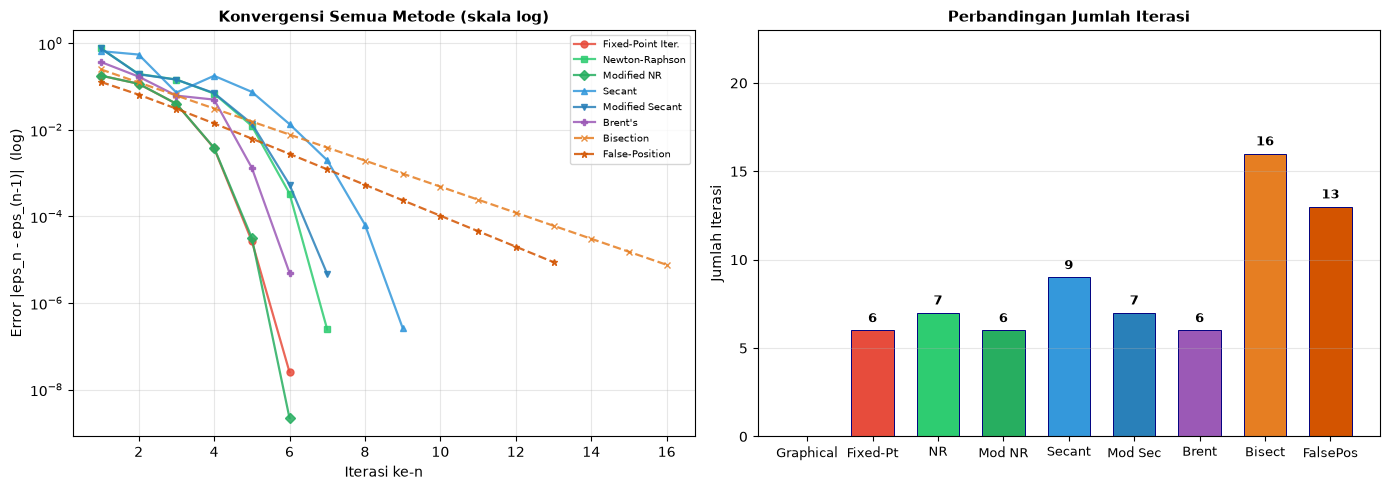

In [63]:
styles = {
    'Fixed-Point Iter.': ('o-',  '#e74c3c'),
    'Newton-Raphson'   : ('s-',  '#2ecc71'),
    'Modified NR'      : ('D-',  '#27ae60'),
    'Secant'           : ('^-',  '#3498db'),
    'Modified Secant'  : ('v-',  '#2980b9'),
    "Brent's"          : ('P-',  '#9b59b6'),
    'Bisection'        : ('x--', '#e67e22'),
    'False-Position'   : ('*--', '#d35400'),
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for name, res in results_all.items():
    mk, col = styles[name]
    errs = res['errors']
    if errs:
        ax.semilogy(range(1, len(errs)+1), errs,
                    mk, color=col, lw=1.6, ms=5, label=name, alpha=0.85)
ax.set_xlabel('Iterasi ke-n', fontsize=10)
ax.set_ylabel('Error |eps_n - eps_(n-1)|  (log)', fontsize=10)
ax.set_title('Konvergensi Semua Metode (skala log)', fontsize=11, fontweight='bold')
ax.legend(fontsize=7.5, loc='upper right')
ax.grid(True, which='both', alpha=0.3)

ax2 = axes[1]
names_bar = ['Graphical', 'Fixed-Pt', 'NR', 'Mod NR', 'Secant', 'Mod Sec', "Brent", 'Bisect', 'FalsePos']
iters_bar = [0,
             res_fpi['iterations'],  res_nr['iterations'],
             res_mnr['iterations'],  res_sec['iterations'],
             res_msec['iterations'], res_brent['iterations'],
             res_bis['iterations'],  res_fp['iterations']]
bcolors = ['#95a5a6', '#e74c3c', '#2ecc71', '#27ae60',
           '#3498db', '#2980b9', '#9b59b6', '#e67e22', '#d35400']

bars2 = ax2.bar(names_bar, iters_bar, color=bcolors,
                edgecolor='navy', linewidth=0.7, width=0.65)
for bar, val in zip(bars2, iters_bar):
    if val > 0:
        ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                 str(val), ha='center', va='bottom', fontsize=9, fontweight='bold')
ax2.set_ylabel('Jumlah Iterasi', fontsize=10)
ax2.set_title('Perbandingan Jumlah Iterasi', fontsize=11, fontweight='bold')
ax2.set_ylim(0, max(iters_bar)*1.25 + 3)
ax2.tick_params(axis='x', labelsize=9)
ax2.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('perbandingan_metode.png', dpi=130, bbox_inches='tight')
plt.show()


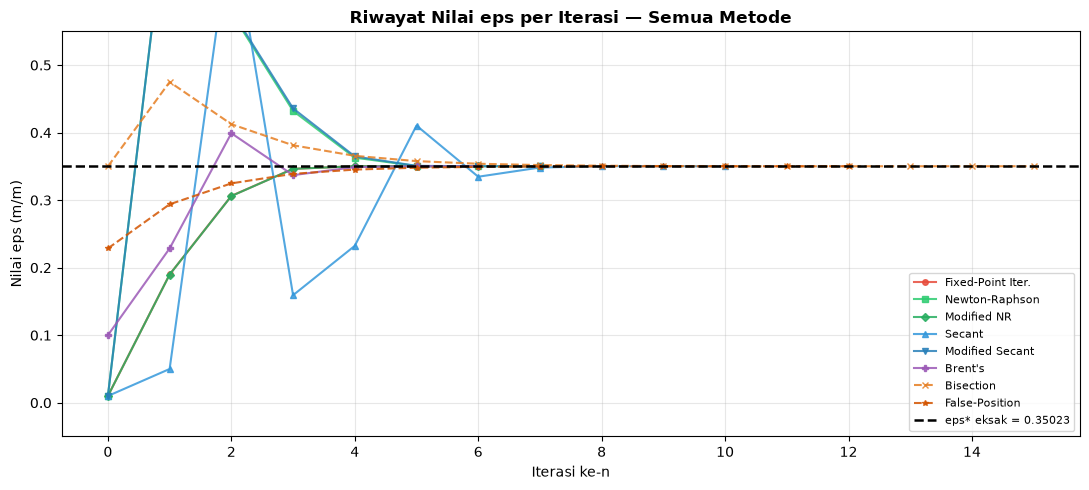

In [64]:
fig, ax = plt.subplots(figsize=(11, 5))
for name, res in results_all.items():
    mk, col = styles[name]
    hist = res['history']
    ax.plot(range(len(hist)), hist, mk, color=col,
            lw=1.5, ms=4, label=name, alpha=0.85)
ax.axhline(eps_star, color='k', lw=1.8, ls='--',
           label=f'eps* eksak = {eps_star:.5f}', zorder=10)
ax.set_xlabel('Iterasi ke-n', fontsize=10)
ax.set_ylabel('Nilai eps (m/m)', fontsize=10)
ax.set_title('Riwayat Nilai eps per Iterasi — Semua Metode', fontsize=12, fontweight='bold')
ax.set_ylim(-0.05, 0.55)
ax.legend(fontsize=8, loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('riwayat_konvergensi.png', dpi=130, bbox_inches='tight')
plt.show()


## 6. Kesimpulan

1. **Regresi** centered finite difference: $a=4{,}2537$, $E_0=1\,518\,928{,}89\,\mathrm{N/m^2}$ ($R^2=0{,}971782$) — konsisten manual, `linregress`, `polyfit`.
2. **Inverse model** beri $\varepsilon_{\mathrm{exact}}$ 13 kandidat $0{,}052$–$0{,}602$; semua sign-change pada $[0{,}001,0{,}85]$ → metode tertutup dapat dipakai.
3. **Weighted scoring 5 kriteria** (K1 25% + K2 20% + K3 25% + K4 15% + K5 15%): **$i=8$ ($\sigma=1\,227\,000\,\mathrm{N/m^2}$, $\varepsilon_{\mathrm{exact}}\approx0{,}350233$)** peringkat 1 skor **1.00 (5/5)**; berikut $i=7$ skor $0.85$.
4. Dengan $\sigma_{target}$ terpilih:
   - **Metode terbuka** ($\varepsilon_0=0{,}01$) konvergen ke $\approx0{,}350233$ ($ea<10^{-5}$, $maxit=50$): fixed-point 6, Newton 7, Mod-Newton 6, secant 9, Mod-secant 7 iterasi; $\alpha=1/f'(0{,}35)$ menstabilkan fixed-point.
   - **Metode tertutup/hibrida** stabil di $[0{,}1,0{,}6]$: Brent 6, biseksi 16, false-position 13 iterasi (falsi satu sisi, wajar lebih lambat).

> **Rekomendasi: gunakan $\boxed{\sigma_{target}=1\,227\,000\,\mathrm{N/m^2}\;(i=8)}$** — tengah, *well-conditioned*, konsisten model. Cadangan $i=7$ ($833\,\mathrm{k}$).
> **Catatan sisa:** $f(\varepsilon_{\mathrm{data}})$ besar sistematis karena fit di ruang turunan; dinilai via K4 turunan, akar $f(\varepsilon^*)=0$ tetap sah.


In [65]:
# --- Ringkasan akhir (salin manual ke .docx bila perlu) ---
eps_data_i8 = dict(zip(range(1,14), eps_all))[8]
print(f"E0 = {E0:.2f} N/m2")
print(f"a  = {a:.6f}")
print(f"R2 = {r2_manual:.6f}")
print(f"\nSigma target terpilih: {sigma_target} N/m2 (i=8)")
print(f"Epsilon exact ≈ {eps_star:.6f}")
print(f"Epsilon data : {eps_data_i8:.3f}")
print(f"Braket valid: [0,1; 0,6]  f(0,1)={f(0.1):.0f}  f(0,6)={f(0.6):.0f}")


E0 = 1518928.89 N/m2
a  = 4.253735
R2 = 0.971782

Sigma target terpilih: 1227000 N/m2 (i=8)
Epsilon exact ≈ 0.350233
Epsilon data : 0.512
Braket valid: [0,1; 0,6]  f(0,1)=-1037689  f(0,6)=2999355
